In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:

df = pd.read_csv("dataset_mood_smartphone.csv")
print(df.head())
print(df.info())
print(df.describe())
df['variable'].value_counts()
df.isna().sum()
df['time'] = pd.to_datetime(df['time'])
df['date'] = df['time'].dt.date




# mood = df[df['variable'] == 'mood'].copy()
# sns.lineplot(x=mood['time'], y=mood['value'])

# plt.title("Mood Over Time")
# plt.xlabel("Time")
# plt.ylabel("Mood")
# plt.show()




   Unnamed: 0       id                     time variable  value
0           1  AS14.01  2014-02-26 13:00:00.000     mood    6.0
1           2  AS14.01  2014-02-26 15:00:00.000     mood    6.0
2           3  AS14.01  2014-02-26 18:00:00.000     mood    6.0
3           4  AS14.01  2014-02-26 21:00:00.000     mood    7.0
4           5  AS14.01  2014-02-27 09:00:00.000     mood    6.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  object 
 2   time        376912 non-null  object 
 3   variable    376912 non-null  object 
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 14.4+ MB
None
         Unnamed: 0          value
count  3.769120e+05  376710.000000
mean   4.501273e+05      40.665313
std    5.411519e+05     273.726007
min 

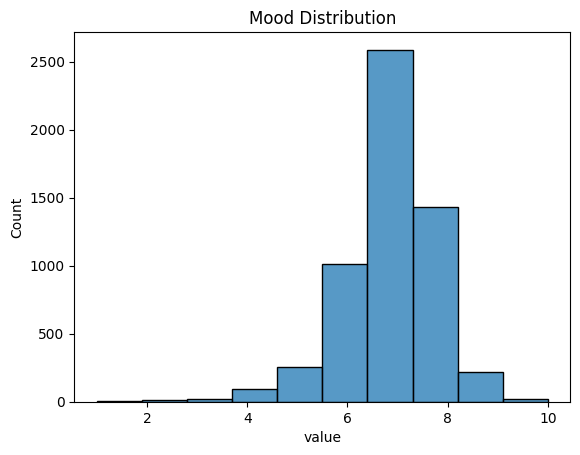

In [14]:
sns.histplot(df[df.variable=='mood']['value'], bins=10)
plt.title("Mood Distribution")
plt.show()

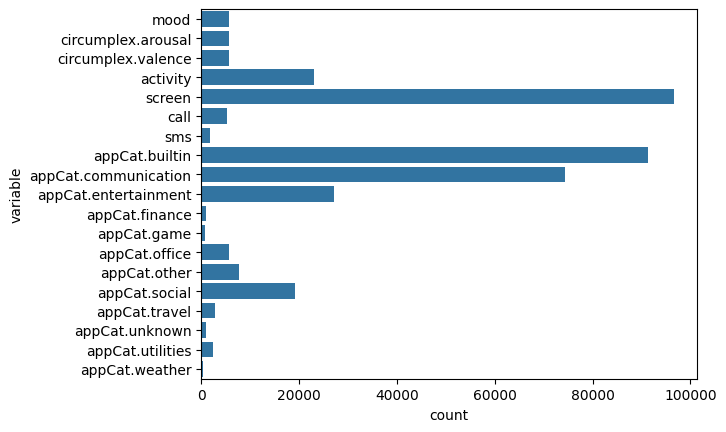

In [15]:
sns.countplot(y='variable', data=df)
plt.show()

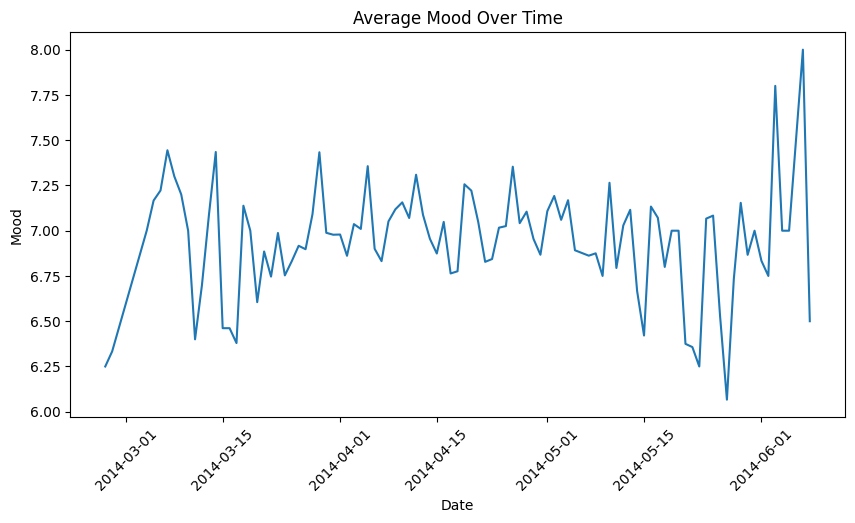

In [16]:
import numpy as np
import matplotlib.pyplot as plt

mood = df[df['variable'] == 'mood'].copy()

mood['time'] = pd.to_datetime(mood['time'])
mood['date'] = mood['time'].dt.floor('D')

daily_mood = mood.groupby('date')['value'].mean().reset_index()

x = np.asarray(daily_mood['date'])
y = np.asarray(daily_mood['value'])

plt.figure(figsize=(10,5))
plt.plot(x, y)

plt.title("Average Mood Over Time")
plt.xlabel("Date")
plt.ylabel("Mood")
plt.xticks(rotation=45)
plt.show()

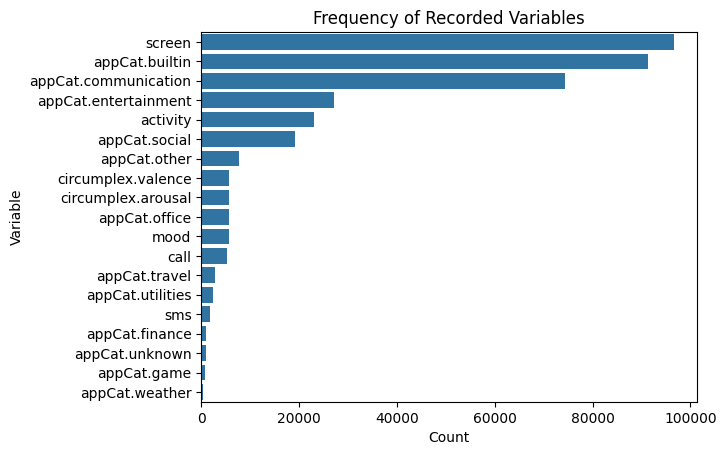

In [17]:
sns.countplot(y=df['variable'], order=df['variable'].value_counts().index)

plt.title("Frequency of Recorded Variables")
plt.xlabel("Count")
plt.ylabel("Variable")
plt.show()

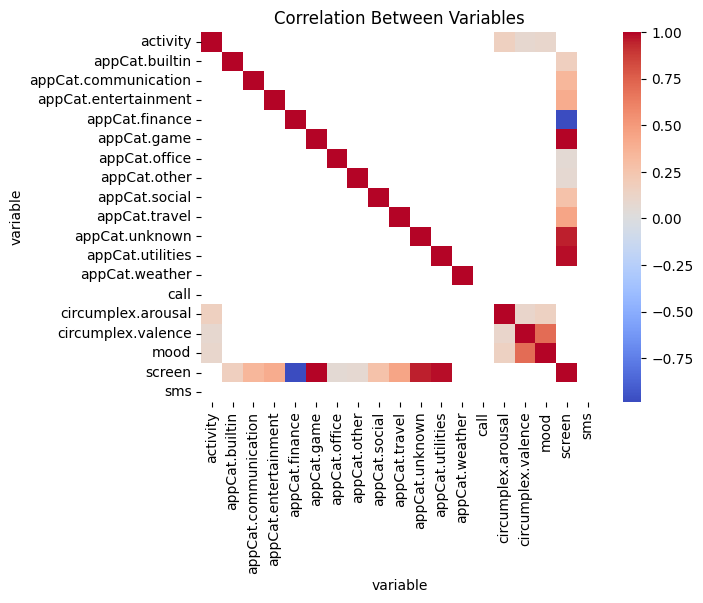

In [18]:
pivot = df.pivot_table(
    index=['id','time'],
    columns='variable',
    values='value'
)

corr = pivot.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Between Variables")
plt.show()

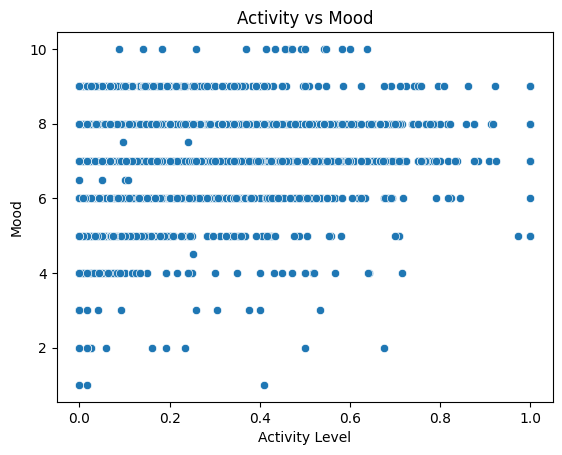

In [19]:
sns.scatterplot(x=pivot['activity'], y=pivot['mood'])

plt.title("Activity vs Mood")
plt.xlabel("Activity Level")
plt.ylabel("Mood")
plt.show()

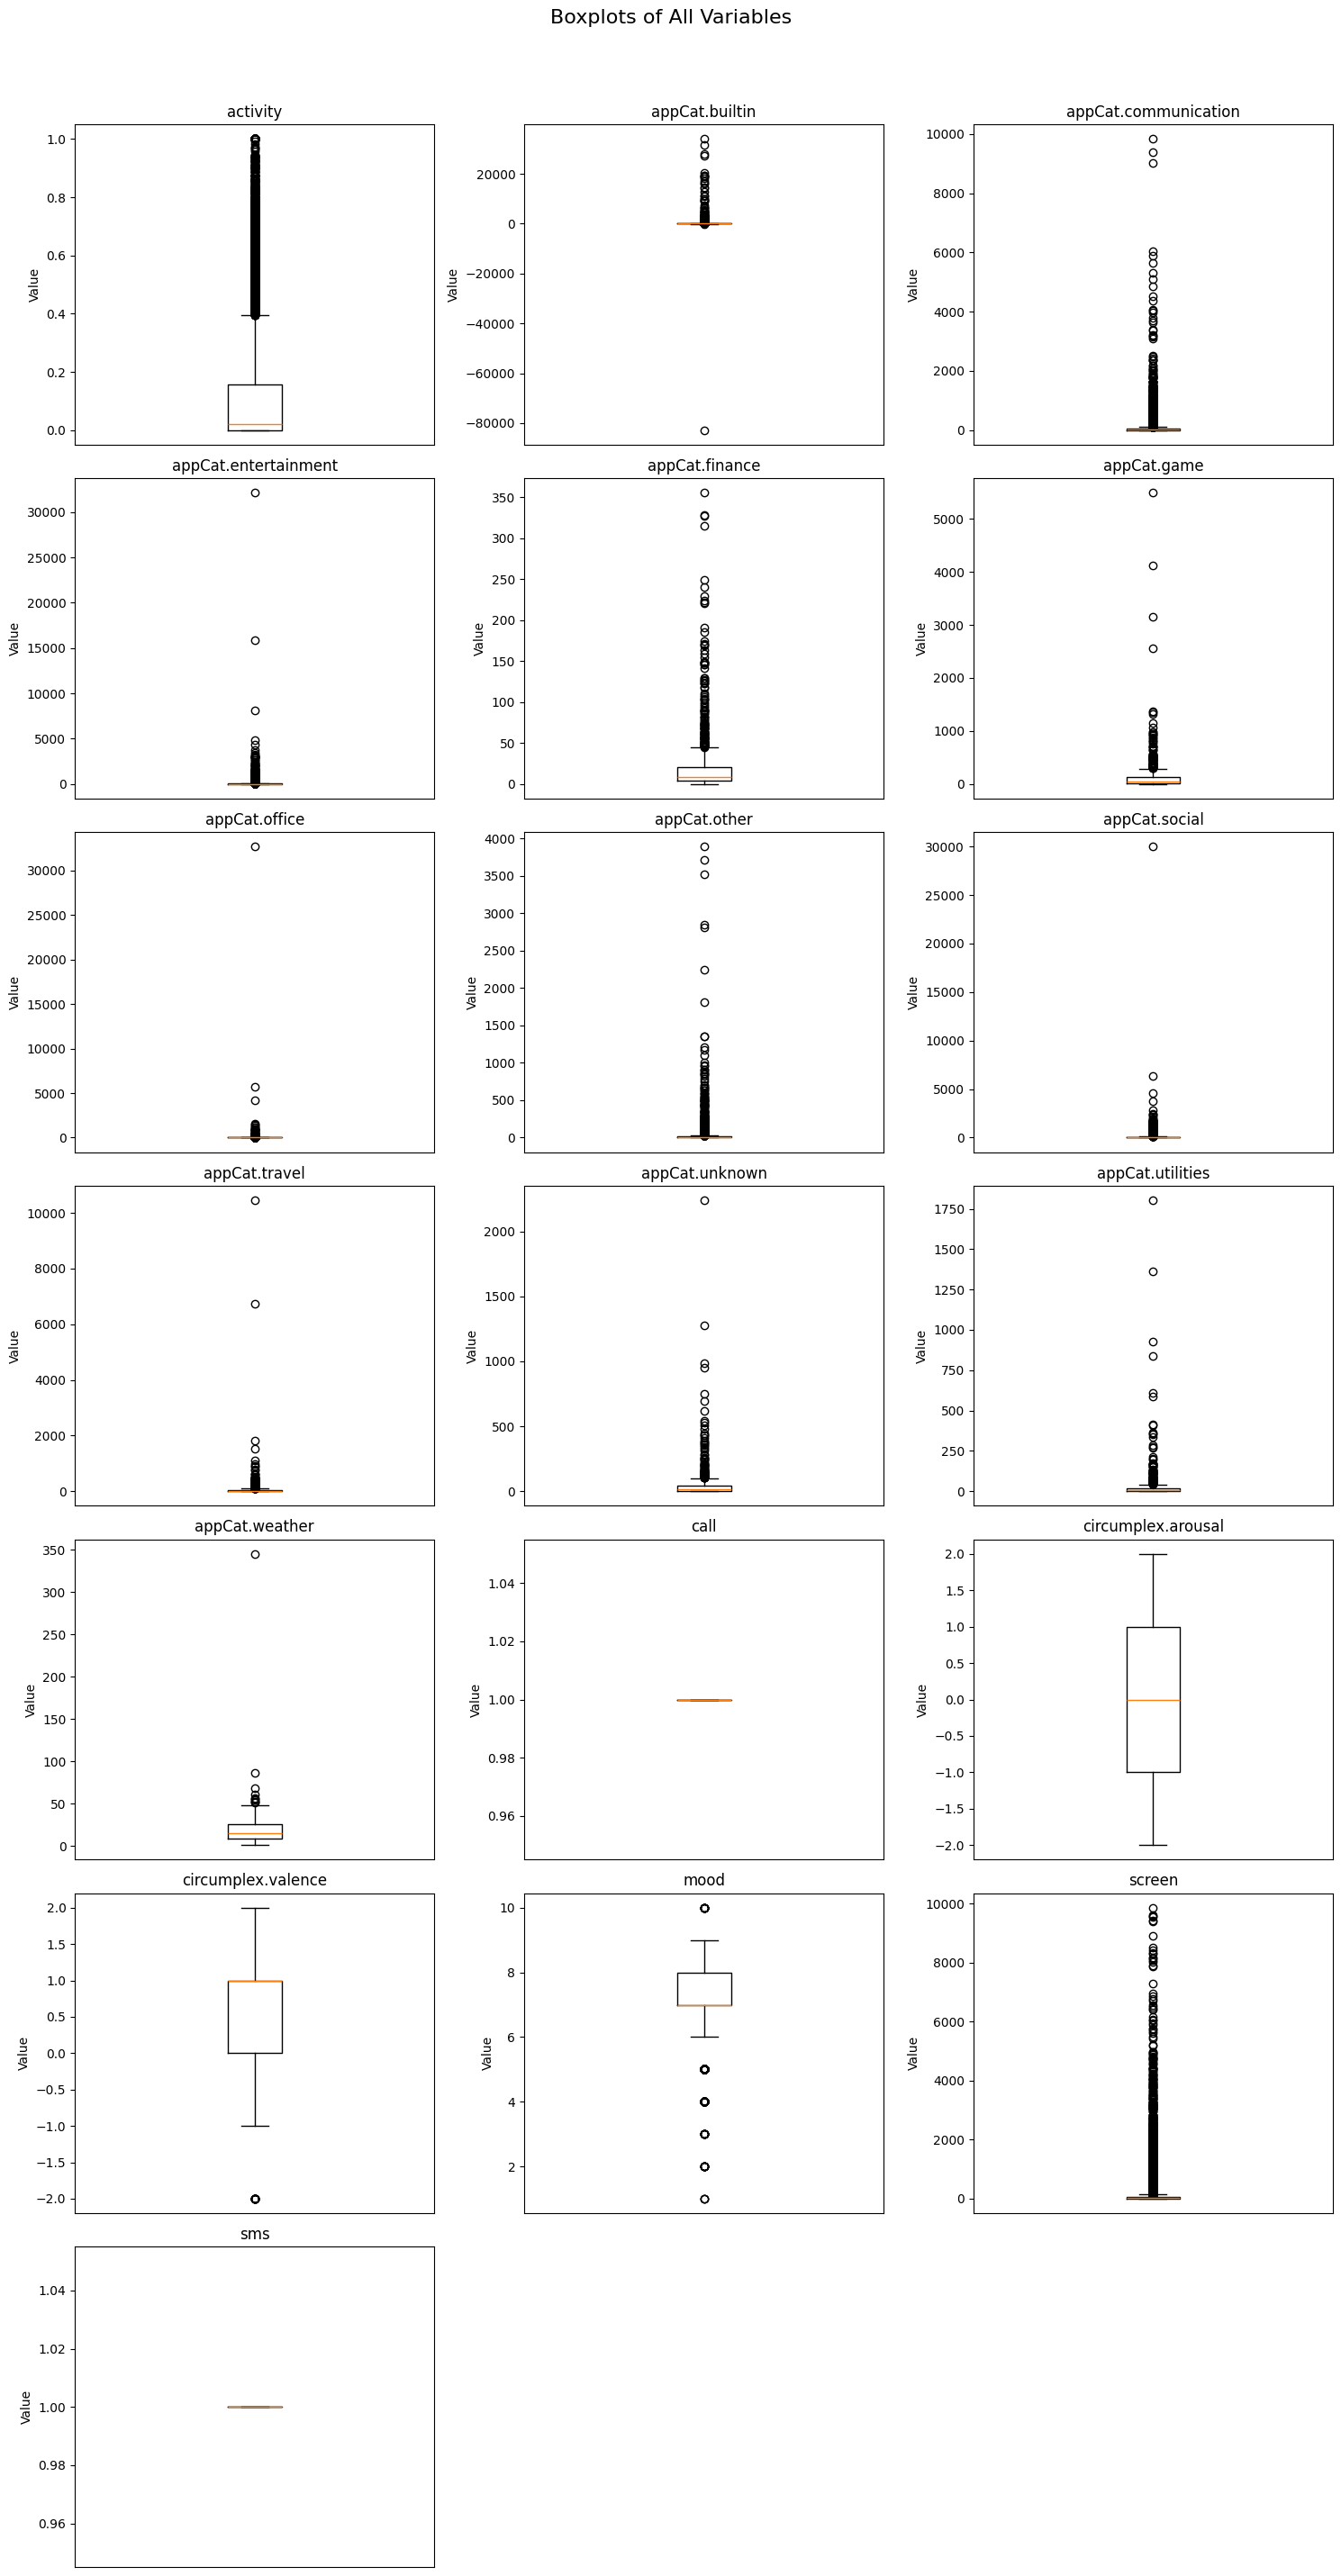

In [21]:
variables = df['variable'].unique()
n = len(variables)
ncols = 3
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(sorted(variables)):
    data = df[df['variable'] == var]['value'].dropna()
    axes[i].boxplot(data, vert=True)
    axes[i].set_title(var)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of All Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

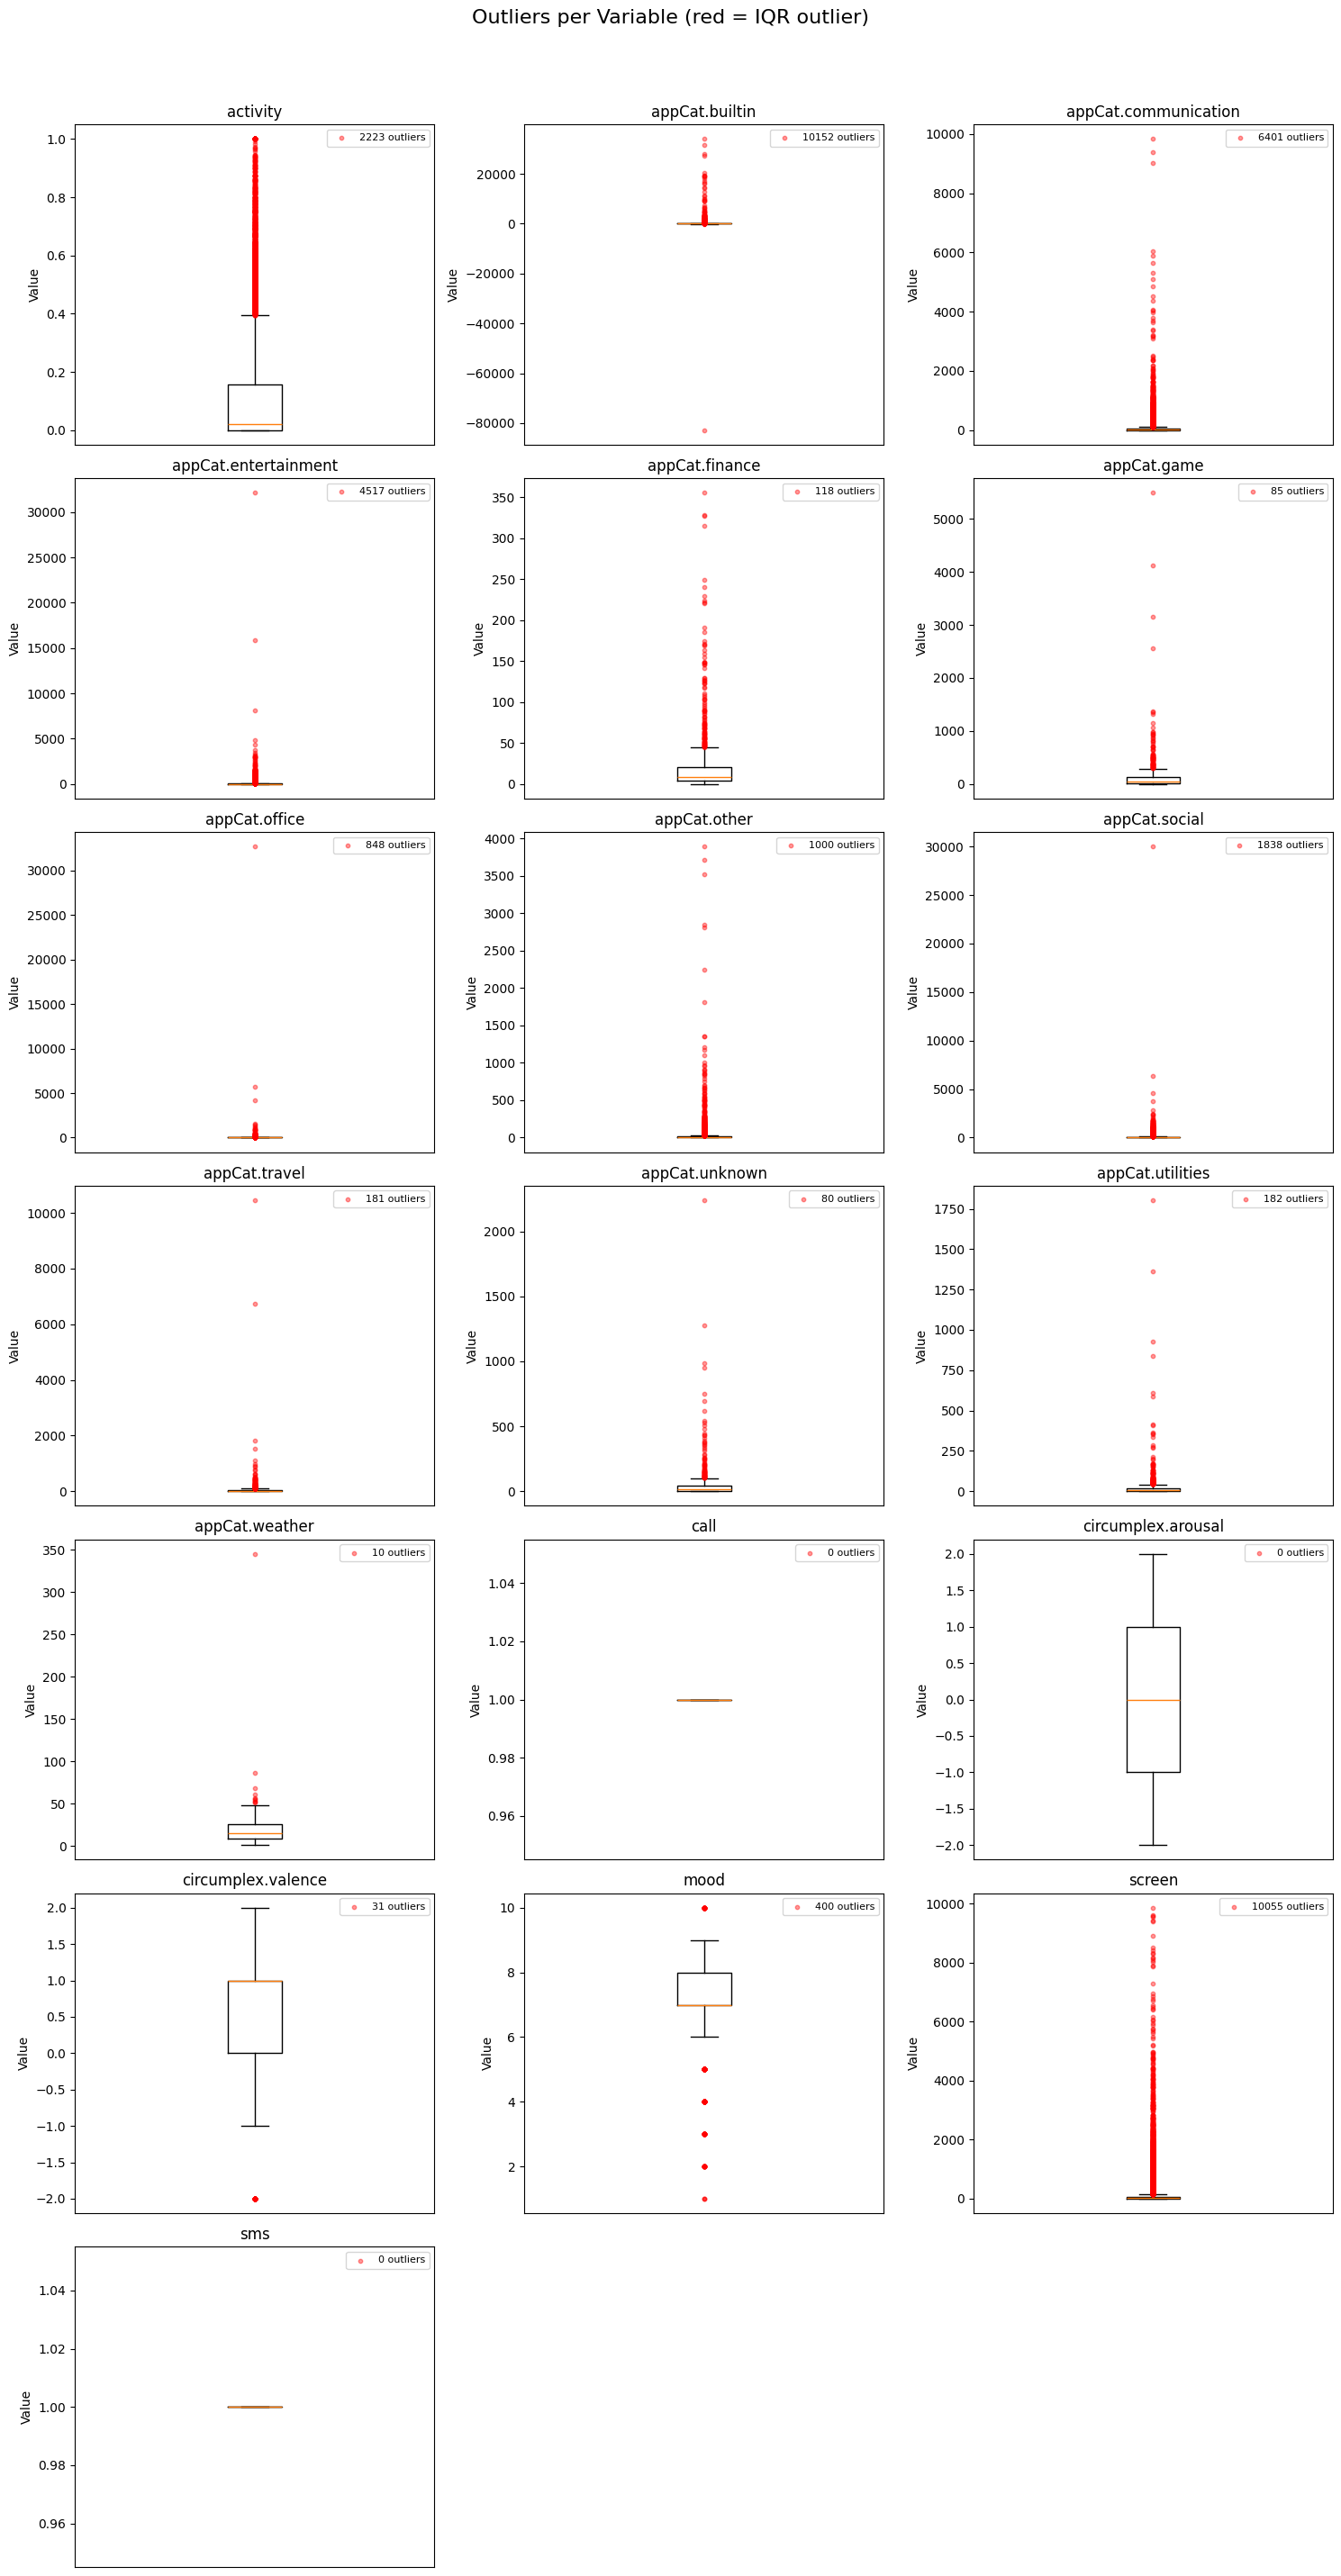

In [22]:
def get_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return series[(series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)]

variables = sorted(df['variable'].unique())
ncols = 3
nrows = -(-len(variables) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, var in enumerate(variables):
    data = df[df['variable'] == var]['value'].dropna()
    outliers = get_outliers(data)

    ax = axes[i]
    ax.boxplot(data, vert=True, flierprops=dict(marker='o', color='white', alpha=0))
    ax.scatter(
        [1] * len(outliers), outliers,
        color='red', alpha=0.4, s=10, zorder=3, label=f'{len(outliers)} outliers'
    )
    ax.set_title(var)
    ax.set_ylabel('Value')
    ax.set_xticks([])
    ax.legend(fontsize=8, loc='upper right')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Outliers per Variable (red = IQR outlier)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

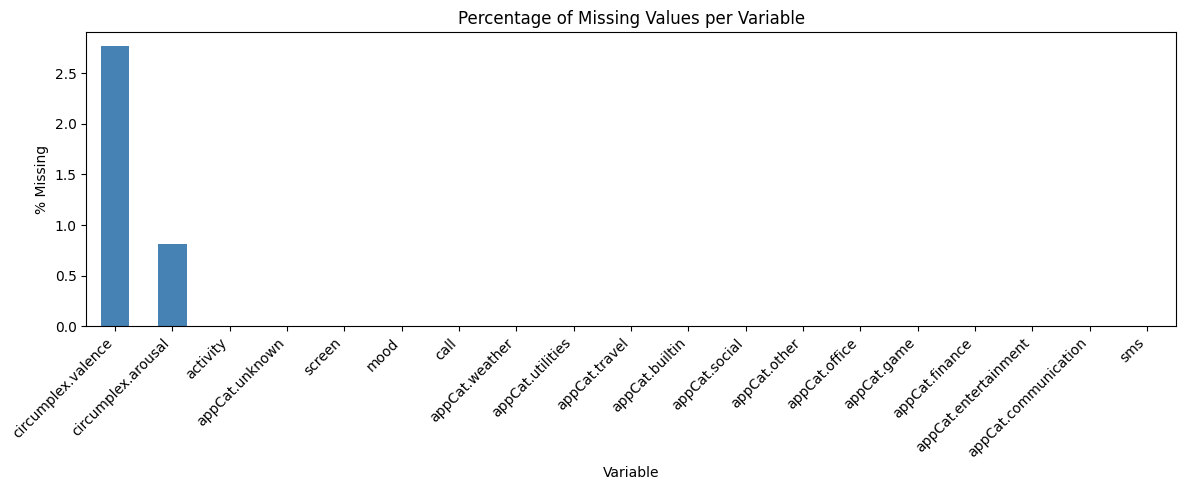

In [23]:
# Missing values per variable
missing = df.groupby('variable')['value'].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
missing.plot(kind='bar', color='steelblue')
plt.title("Percentage of Missing Values per Variable")
plt.ylabel("% Missing")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

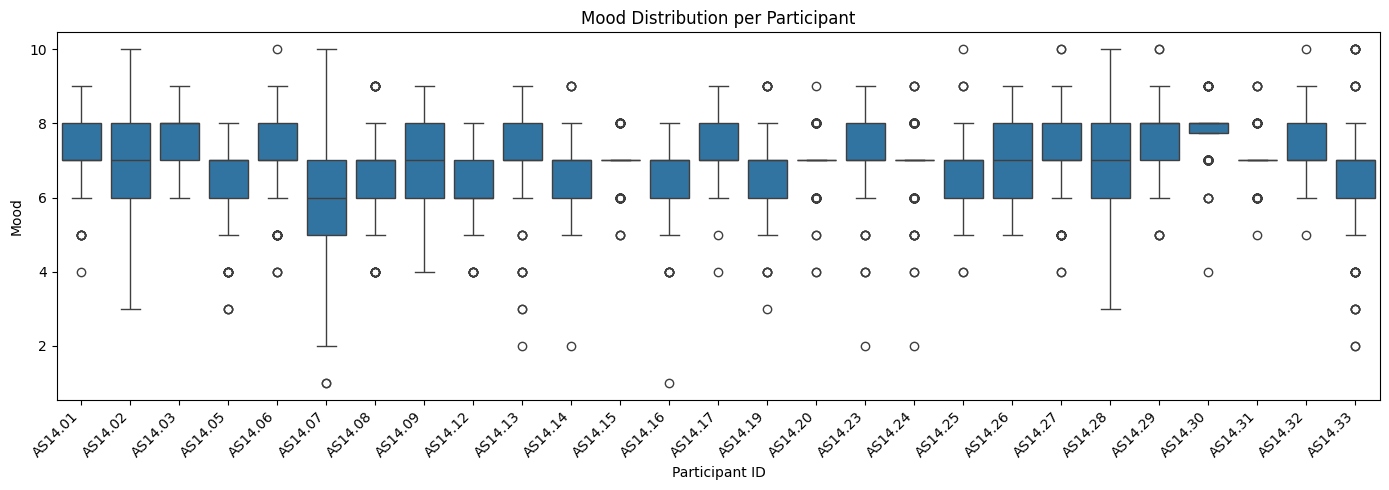

In [24]:
# Mood distribution per participant
mood_df = df[df['variable'] == 'mood']

plt.figure(figsize=(14, 5))
sns.boxplot(x='id', y='value', data=mood_df, order=sorted(mood_df['id'].unique()))
plt.title("Mood Distribution per Participant")
plt.xlabel("Participant ID")
plt.ylabel("Mood")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

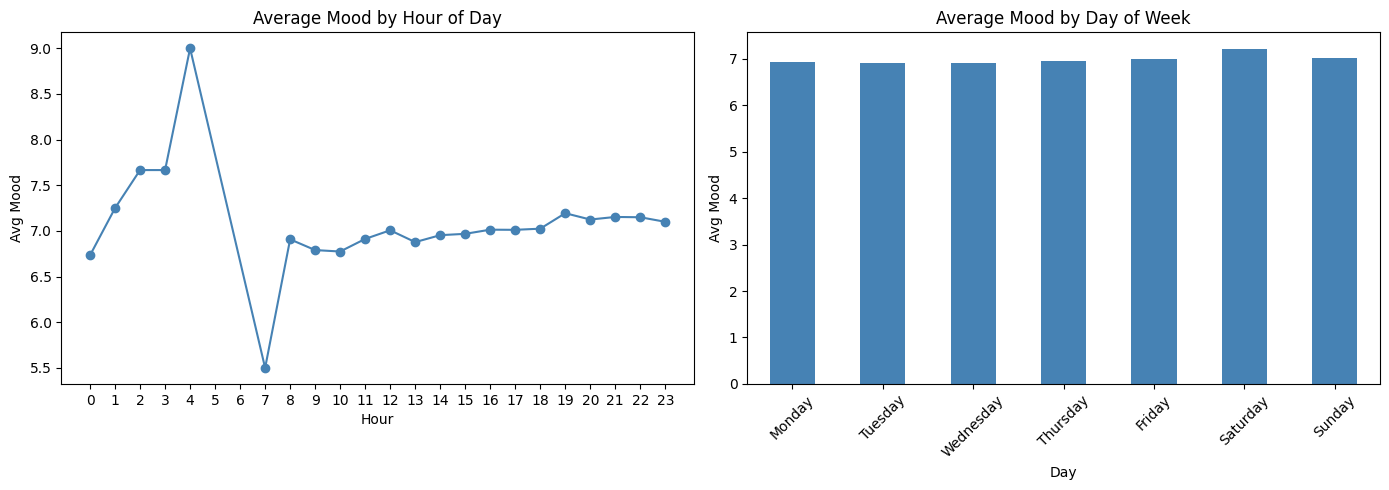

In [25]:
# Mood by hour of day and day of week
mood_time = df[df['variable'] == 'mood'].copy()
mood_time['hour'] = mood_time['time'].dt.hour
mood_time['dayofweek'] = mood_time['time'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mood_time.groupby('hour')['value'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title("Average Mood by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Avg Mood")
axes[0].set_xticks(range(0, 24))

mood_time.groupby('dayofweek')['value'].mean().reindex(day_order).plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title("Average Mood by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Avg Mood")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

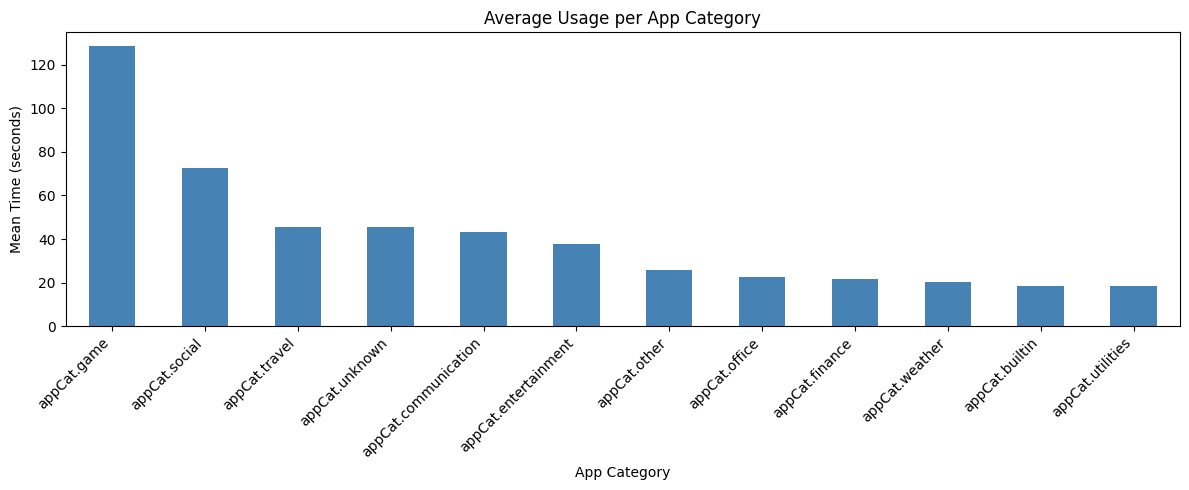

In [26]:
# Average app category usage
app_cats = [v for v in df['variable'].unique() if v.startswith('appCat')]
app_means = pd.Series({cat: df[df['variable'] == cat]['value'].mean() for cat in app_cats}).sort_values(ascending=False)

plt.figure(figsize=(12, 5))
app_means.plot(kind='bar', color='steelblue')
plt.title("Average Usage per App Category")
plt.ylabel("Mean Time (seconds)")
plt.xlabel("App Category")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

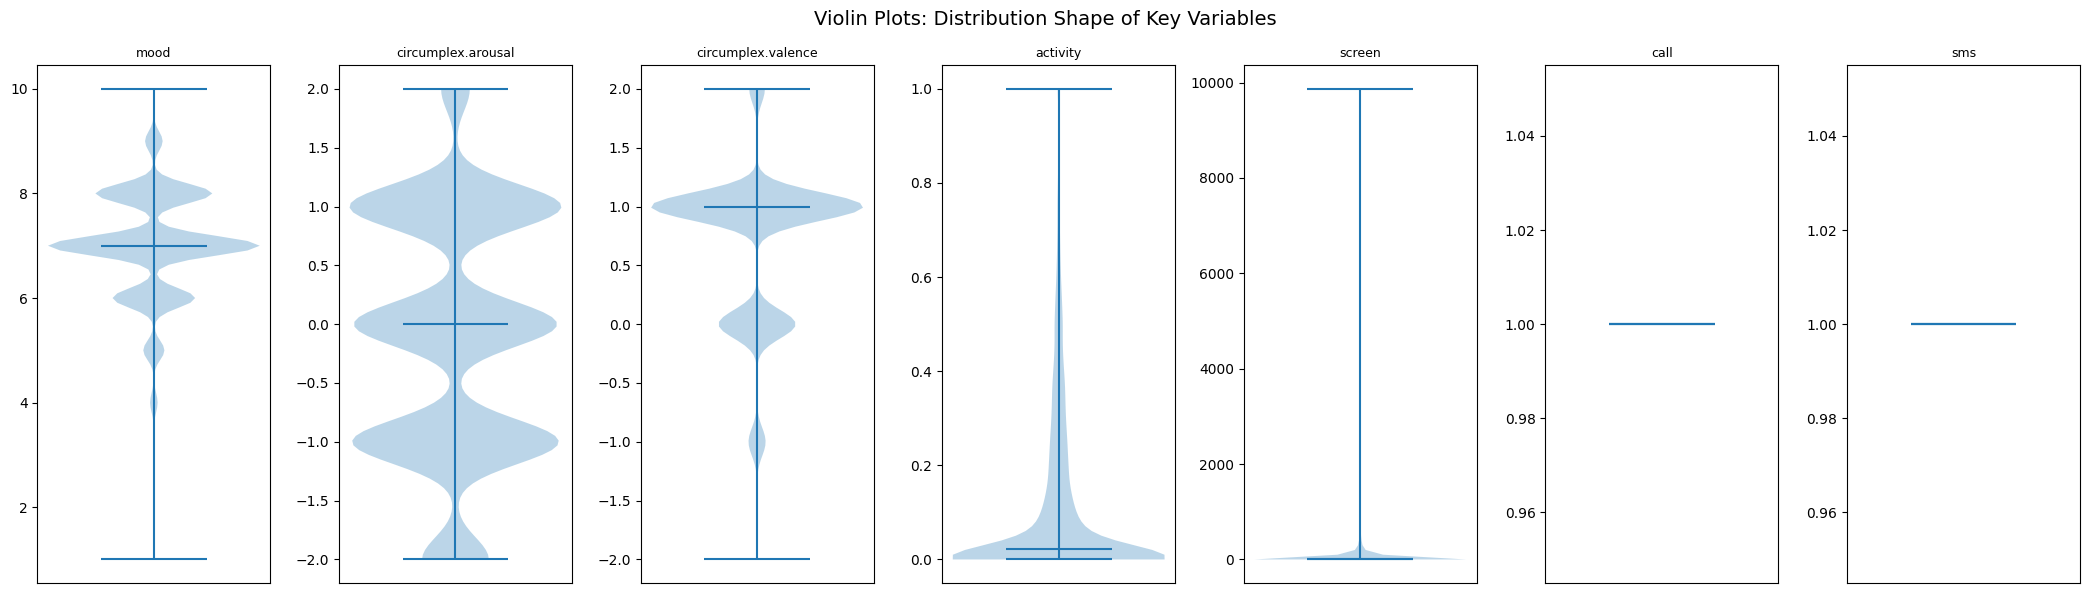

In [27]:
# Violin plots for key variables
key_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity', 'screen', 'call', 'sms']

fig, axes = plt.subplots(1, len(key_vars), figsize=(3 * len(key_vars), 6))

for ax, var in zip(axes, key_vars):
    data = df[df['variable'] == var]['value'].dropna()
    ax.violinplot(data, showmedians=True)
    ax.set_title(var, fontsize=9)
    ax.set_xticks([])

fig.suptitle("Violin Plots: Distribution Shape of Key Variables", fontsize=14)
plt.tight_layout()
plt.show()

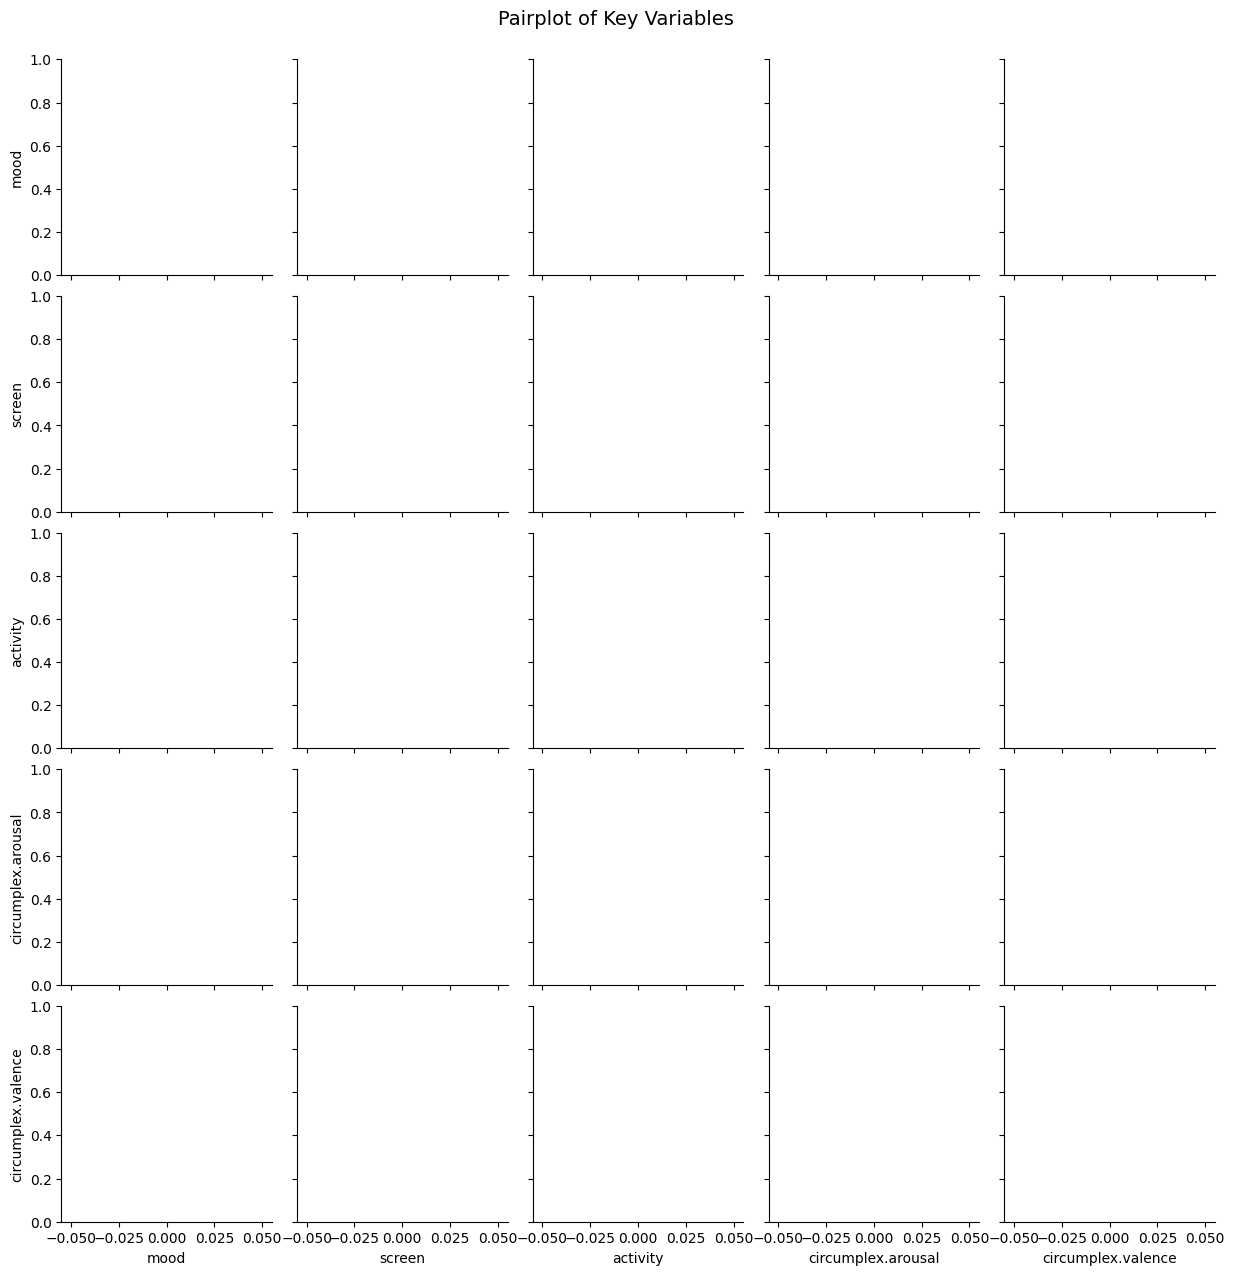

In [28]:
# Pairplot of key variables
pair_vars = ['mood', 'screen', 'activity', 'circumplex.arousal', 'circumplex.valence']
pivot_pair = df[df['variable'].isin(pair_vars)].pivot_table(
    index=['id', 'time'], columns='variable', values='value'
).reset_index(drop=True).dropna()

sns.pairplot(pivot_pair[pair_vars], plot_kws={'alpha': 0.2, 's': 5}, diag_kind='kde')
plt.suptitle("Pairplot of Key Variables", y=1.02, fontsize=14)
plt.show()

In [29]:
# Number of instances per variable
counts = df.groupby('variable')['value'].agg(
    total='count',
    missing=lambda x: x.isna().sum(),
    non_missing='count'
).assign(missing=lambda d: df.groupby('variable')['value'].apply(lambda x: x.isna().sum()).values)

counts.index.name = 'Variable'
counts.columns = ['Total', 'Missing', 'Non-Missing']
counts['Missing %'] = (counts['Missing'] / (counts['Total'] + counts['Missing']) * 100).round(2)
counts = counts.sort_values('Total', ascending=False)

counts

,Total,Missing,Non-Missing,Missing %
Variable,,,,
screen,96578,0,96578,0.00
appCat.builtin,91288,0,91288,0.00
appCat.communication,74276,0,74276,0.00
appCat.entertainment,27125,0,27125,0.00
activity,22965,0,22965,0.00
appCat.social,19145,0,19145,0.00
appCat.other,7650,0,7650,0.00
appCat.office,5642,0,5642,0.00
mood,5641,0,5641,0.00
